In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo consistente con el resto del proyecto
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

In [2]:
df = pd.read_parquet('../data/creditrisk360_eda.parquet')

# Definición de default 
DEFAULT_STATUS = ['Charged Off', 'Late (31-120 days)', 'Does not meet the credit policy. Status:Charged Off']
df_def = df[df['loan_status'].isin(DEFAULT_STATUS)].copy()

print(f"Total dataset:      {len(df):>10,}")
print(f"Préstamos default:  {len(df_def):>10,}  ({len(df_def)/len(df)*100:.1f}%)")


Total dataset:         549,566
Préstamos default:     116,315  (21.2%)


In [3]:
df_def['recovery_total'] = (
    df_def['recoveries'].clip(lower=0) +
    df_def['total_rec_late_fee'].clip(lower=0)
)

# Recovery rate: fracción recuperada sobre el importe desembolsado
# funded_amnt es el denominador correcto (lo que realmente salió del banco)
df_def['recovery_rate'] = (df_def['recovery_total'] / df_def['funded_amnt']).clip(0, 1)

# LGD = fracción perdida
df_def['lgd'] = 1 - df_def['recovery_rate']

print("\n--- Estadísticas LGD ---")
print(df_def['lgd'].describe().round(4))
print(f"\nLGD == 1.0 (pérdida total):   {(df_def['lgd'] == 1.0).mean()*100:.1f}%")
print(f"LGD == 0.0 (recuperación total): {(df_def['lgd'] == 0.0).mean()*100:.1f}%")
print(f"LGD en (0, 1):               {((df_def['lgd'] > 0) & (df_def['lgd'] < 1)).mean()*100:.1f}%")



--- Estadísticas LGD ---
count    116315.0000
mean          0.9300
std           0.0930
min           0.0000
25%           0.8919
50%           0.9480
75%           1.0000
max           1.0000
Name: lgd, dtype: float64

LGD == 1.0 (pérdida total):   31.0%
LGD == 0.0 (recuperación total): 0.0%
LGD en (0, 1):               68.9%


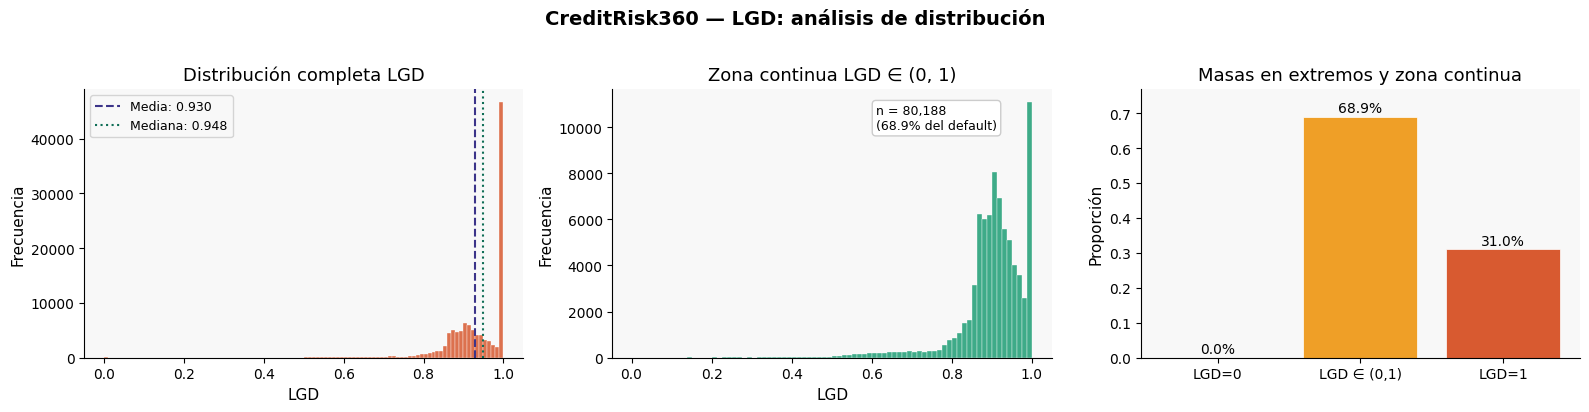

In [4]:
# 3. EDA — DISTRIBUCIÓN LGD
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CreditRisk360 — LGD: análisis de distribución', fontsize=14, fontweight='bold', y=1.02)

# 3.1 Histograma completo
ax = axes[0]
ax.hist(df_def['lgd'], bins=100, color='#D85A30', edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(df_def['lgd'].mean(), color='#3C3489', lw=1.5, linestyle='--', label=f"Media: {df_def['lgd'].mean():.3f}")
ax.axvline(df_def['lgd'].median(), color='#0F6E56', lw=1.5, linestyle=':', label=f"Mediana: {df_def['lgd'].median():.3f}")
ax.set_title('Distribución completa LGD')
ax.set_xlabel('LGD')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

# 3.2 Zoom zona (0, 1) — excluyendo masas en extremos
ax = axes[1]
lgd_mid = df_def['lgd'][(df_def['lgd'] > 0) & (df_def['lgd'] < 1)]
ax.hist(lgd_mid, bins=80, color='#1D9E75', edgecolor='white', linewidth=0.3, alpha=0.85)
ax.set_title('Zona continua LGD ∈ (0, 1)')
ax.set_xlabel('LGD')
ax.set_ylabel('Frecuencia')
ax.annotate(f"n = {len(lgd_mid):,}\n({len(lgd_mid)/len(df_def)*100:.1f}% del default)",
            xy=(0.6, 0.85), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ccc'))

# 3.3 Masses at extremes — bar chart
ax = axes[2]
mass_zero  = (df_def['lgd'] == 0.0).mean()
mass_mid   = ((df_def['lgd'] > 0) & (df_def['lgd'] < 1)).mean()
mass_one   = (df_def['lgd'] == 1.0).mean()
bars = ax.bar(['LGD=0', 'LGD ∈ (0,1)', 'LGD=1'],
              [mass_zero, mass_mid, mass_one],
              color=['#1D9E75', '#EF9F27', '#D85A30'],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, [mass_zero, mass_mid, mass_one]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Masas en extremos y zona continua')
ax.set_ylabel('Proporción')
ax.set_ylim(0, max(mass_zero, mass_mid, mass_one) + 0.08)

plt.tight_layout()
plt.savefig('../outputs/06_lgd_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()


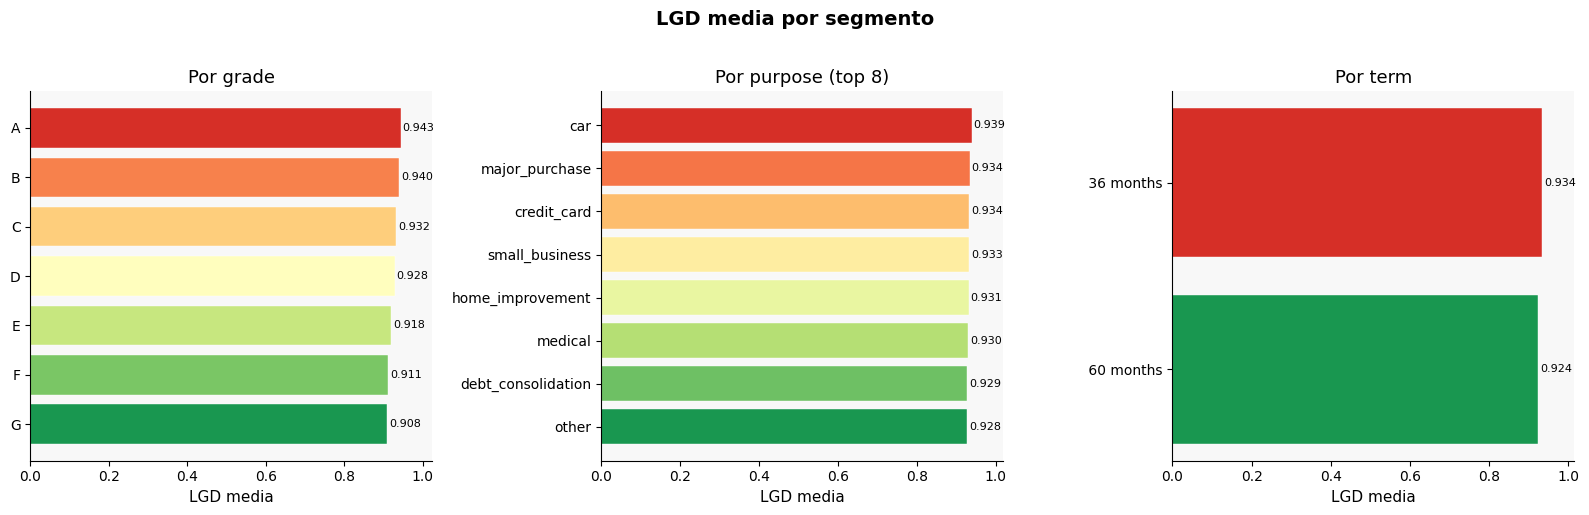

In [5]:
# 4. LGD POR SEGMENTO (grade, purpose, term)
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('LGD media por segmento', fontsize=14, fontweight='bold', y=1.02)

for ax, col, title in zip(
    axes,
    ['grade', 'purpose', 'term'],
    ['Por grade', 'Por purpose (top 8)', 'Por term']
):
    if col == 'purpose':
        top_cats = df_def['purpose'].value_counts().head(8).index
        data = df_def[df_def['purpose'].isin(top_cats)]
    else:
        data = df_def

    seg_stats = (data.groupby(col)['lgd']
                 .agg(['mean', 'std', 'count'])
                 .sort_values('mean', ascending=True)
                 .reset_index())

    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(seg_stats)))
    bars = ax.barh(seg_stats[col].astype(str), seg_stats['mean'],
                   color=colors, edgecolor='white', linewidth=0.3)
    for bar, (_, row) in zip(bars, seg_stats.iterrows()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{row['mean']:.3f}", va='center', fontsize=8)
    ax.set_xlabel('LGD media')
    ax.set_title(title)
    ax.set_xlim(0, seg_stats['mean'].max() + 0.08)

plt.tight_layout()
plt.savefig('../outputs/06_lgd_por_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

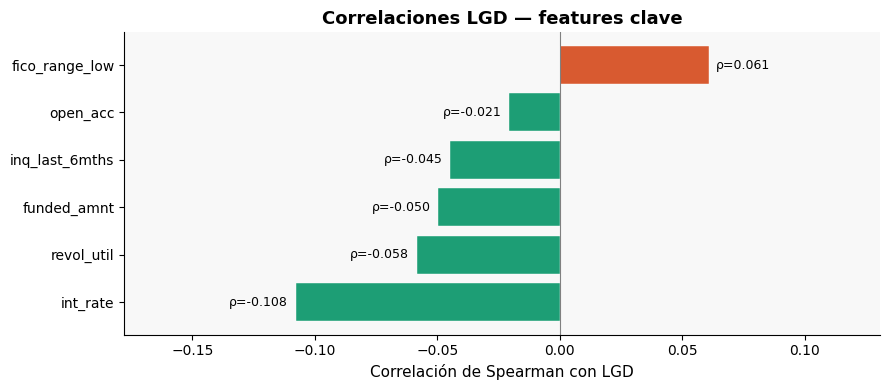


--- Correlaciones Spearman con LGD ---
                   rho    p
int_rate       -0.1078  0.0
revol_util     -0.0584  0.0
funded_amnt    -0.0496  0.0
inq_last_6mths -0.0446  0.0
open_acc       -0.0206  0.0
fico_range_low  0.0608  0.0


In [6]:
# 5. CORRELACIÓN LGD vs FEATURES CLAVE
# ──────────────────────────────────────────────

features_corr = [
    'fico_range_low', 'int_rate', 'log_dti', 'log_annual_inc',
    'revol_util', 'open_acc', 'inq_last_6mths', 'funded_amnt'
]

corr_vals = {}
for feat in features_corr:
    if feat in df_def.columns:
        mask = df_def[feat].notna() & df_def['lgd'].notna()
        r, p = stats.spearmanr(df_def.loc[mask, feat], df_def.loc[mask, 'lgd'])
        corr_vals[feat] = (r, p)

corr_df = pd.DataFrame(corr_vals, index=['rho', 'p']).T.sort_values('rho')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#D85A30' if v > 0 else '#1D9E75' for v in corr_df['rho']]
bars = ax.barh(corr_df.index, corr_df['rho'], color=colors, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='gray', lw=0.8)
for bar, (feat, row) in zip(bars, corr_df.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.003 if x >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f"ρ={row['rho']:.3f}", va='center', ha=('left' if x >= 0 else 'right'), fontsize=9)
ax.set_xlabel('Correlación de Spearman con LGD')
ax.set_title('Correlaciones LGD — features clave', fontsize=13, fontweight='bold')
ax.set_xlim(corr_df['rho'].min() - 0.07, corr_df['rho'].max() + 0.07)
plt.tight_layout()
plt.savefig('../outputs/06_lgd_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Correlaciones Spearman con LGD ---")
print(corr_df.round(4).to_string())


In [7]:
# 6. PREPARAR DATASET PARA MODELIZACIÓN
# ──────────────────────────────────────────────

# Variable auxiliar para two-stage: ¿hubo alguna recuperación?
df_def['had_recovery'] = (df_def['lgd'] < 1.0).astype(int)


# ── 1. Encoding ordinal (consistente con Semana 2) ──────────

grade_map = {'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1}
df_def['grade_enc'] = df_def['grade'].map(grade_map)

sub_grade_map = {g+str(n): (7-i)*5+(5-n) 
                 for i,g in enumerate('ABCDEFG') 
                 for n in range(1,6)}
df_def['sub_grade_enc'] = df_def['sub_grade'].map(sub_grade_map)

term_map = {' 36 months': 36, ' 60 months': 60}
df_def['term_enc'] = df_def['term'].map(term_map)

emp_map = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,
           '4 years':4,'5 years':5,'6 years':6,'7 years':7,
           '8 years':8,'9 years':9,'10+ years':10}
df_def['emp_length_enc'] = df_def['emp_length'].map(emp_map)

# ── 2. Features derivadas ────────────────────────────────────

df_def['log_dti']        = np.log1p(df_def['dti'].clip(lower=0))
df_def['log_annual_inc'] = np.log1p(df_def['annual_inc'].clip(lower=0))
df_def['never_delinq']   = (df_def['mths_since_last_delinq'].isna()).astype(int)
df_def['mths_since_last_delinq'] = df_def['mths_since_last_delinq'].fillna(0)
df_def['grade_dti']      = df_def['grade_enc'] * df_def['log_dti']

# fico_bin ordinal
df_def['fico_bin'] = pd.cut(df_def['fico_range_low'],
                             bins=[0,580,620,660,700,740,780,850],
                             labels=[1,2,3,4,5,6,7]).astype(float)

# ── 3. Dummies ───────────────────────────────────────────────

df_def = pd.get_dummies(df_def,
                         columns=['purpose','home_ownership','verification_status'],
                         drop_first=True,
                         dtype=int)

# ── 4. Feature list final ────────────────────────────────────

base_features = [
    'grade_enc','sub_grade_enc','term_enc','emp_length_enc',
    'fico_range_low','int_rate','log_dti','revol_util',
    'log_annual_inc','open_acc','delinq_2yrs','inq_last_6mths',
    'pub_rec','mort_acc','pub_rec_bankruptcies',
    'mths_since_last_delinq','never_delinq','fico_bin','grade_dti'
]
dummy_cols = [c for c in df_def.columns
              if any(c.startswith(p) for p in ['purpose_','home_','verification_'])]

feature_cols = base_features + dummy_cols
feature_cols = [c for c in feature_cols if c in df_def.columns]

print(f"Features totales: {len(feature_cols)}")
print(f"Shape dataset:    {df_def.shape}")
print(f"Nulos en X:       {df_def[feature_cols].isna().sum().sum()}")

# Para la etapa 2 (beta regression): solo casos con recuperación parcial
df_def_partial = df_def[df_def['had_recovery'] == 1].copy()

print(f"\n--- Preparación two-stage ---")
print(f"Stage 1 (clasificador): n = {len(df_def):,}")
print(f"  → Positivo (alguna recuperacion): {df_def['had_recovery'].mean()*100:.1f}%")
print(f"Stage 2 (regresor LGD continua): n = {len(df_def_partial):,}")
print(f"  → LGD media en este subconjunto: {df_def_partial['lgd'].mean():.4f}")
print(f"  → LGD std en este subconjunto:   {df_def_partial['lgd'].std():.4f}")

# Guardar
df_def.to_parquet('../data/lgd_dataset.parquet', index=False)
df_def_partial.to_parquet('../data/lgd_partial_dataset.parquet', index=False)
print("\nDatasets guardados: data/lgd_dataset.parquet, data/lgd_partial_dataset.parquet")

Features totales: 39
Shape dataset:    (116315, 71)
Nulos en X:       12677

--- Preparación two-stage ---
Stage 1 (clasificador): n = 116,315
  → Positivo (alguna recuperacion): 69.0%
Stage 2 (regresor LGD continua): n = 80,236
  → LGD media en este subconjunto: 0.8985
  → LGD std en este subconjunto:   0.0966

Datasets guardados: data/lgd_dataset.parquet, data/lgd_partial_dataset.parquet


In [8]:
print(f"lgd_dataset:         {df_def.shape}")
print(f"lgd_partial_dataset: {df_def_partial.shape}")
print(f"Features listas:     {len(feature_cols)}")

lgd_dataset:         (116315, 71)
lgd_partial_dataset: (80236, 71)
Features listas:     39
